In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import astropy.constants as c
import astropy.units  as u

## you can undo the lines below (but it will be fun for making fancy plots!)
# to make the lines below work, you have to download the file 'PostProcessingScripts' from https://github.com/FloorBroekgaarden/common_code
# and put this in the same directory as this one, and then only use the bottom line from this code below 
import sys
# sys.path.append('../../common_code') 
# from PostProcessingScripts import * 

# to make the screen wider
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:

# you will have to change this to your local path where you saved this data file

folder_path =  "/Users/floorbroekgaarden/Downloads/sspc_test_folder/" 
full_path = folder_path + "bps_output.h5"

### read and plot data in simulation: (based on Boesky+23, see paper)

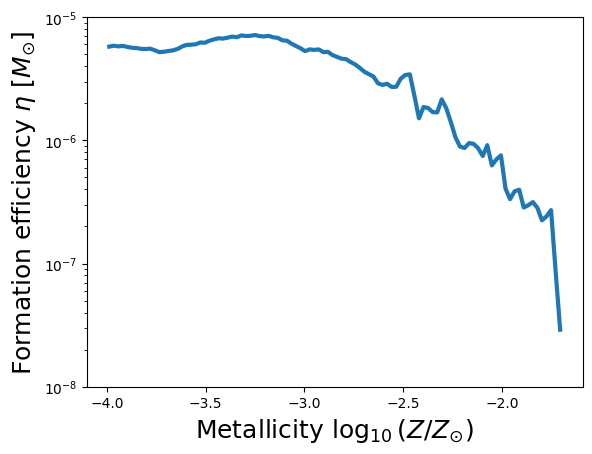

In [3]:
df = pd.read_hdf(full_path, key="input_data")


formation_efficiency_per_solar_mass = df['formation_efficiency_per_solar_mass'].values
metallicities = df["metallicity"].values



# make a plot 

fs=18

hist, bin_edges = np.histogram(np.log10(metallicities), weights=formation_efficiency_per_solar_mass, bins=100, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(formation_efficiency_per_solar_mass)

plt.plot(bin_centers, hist*normalization, lw=3)


plt.yscale('log')
plt.ylim(10**-8, 10**-5)

plt.ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=fs)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=fs)
plt.show()



### to do: 
 - try to plot the delay time distribution instead :) 

## Set up star formation rate (this uses SSPC):



In [4]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
import astropy.units as u
from typing import Union, Dict, List, Tuple, Optional
from dataclasses import dataclass
from pathlib import Path

import os
import json
import pkg_resources
import copy
import logging
import h5py

import copy
import logging
import pandas as pd
import sys

# sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/syntheticstellarpopconvolve')
sys.path.insert(0, '/Users/floorbroekgaarden/Projects/GitHub/syntheticstellarpopconvolve') # fixed this to import sspc in jupyter notebook for me 
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir

from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict

from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import temp_dir, generate_boilerplate_outputfile


In [10]:

# ------------------
# High-level driver
# ------------------

def process_dataset(folder_path, nbins=200, num_redshift_bins=100, sfr_plotting=False):
    """Run the full GROWL convolution processing pipeline for a single dataset."""
    # 1. Compute metallicity bins and SFR dictionary
    sfr_dict = setup_sfr_dict(
         folder_path,
        nbins=nbins, num_redshift_bins=num_redshift_bins
    )

    # 2. Plot SFR dictionary
    if sfr_plotting==True:
        plot_sfr(sfr_dict)

    # 3. Setup output file + copy input data
    output_hdf5_filename, output_hdf5_folder = setup_output_file(folder_path)
    copy_input_data_to_output(folder_path, output_hdf5_filename)

    # 4. Configure convolution
    convolution_config = setup_convolution_config(
        output_hdf5_filename, output_hdf5_folder, sfr_dict)
    
    

    # 5. Run convolution
    convolve(config=convolution_config)

    print(f"✅ Done processing dataset")


# ------------------
# Step 1: SFR + metallicity setup
# ------------------

def setup_sfr_dict(folder_path, nbins=200, num_redshift_bins=100, redshift_min=0, redshift_max=10):
    """Prepare metallicity and SFR distributions for a dataset."""
    full_path = folder_path + "bps_output.h5"
    df = pd.read_hdf(full_path, key="input_data")

    # Metallicities
    metallicities = df["metallicity"].values
    _, log_metallicity_bin_edges = np.histogram(np.log(metallicities), bins=nbins, density=True)
    log_metallicity_bin_centers = (log_metallicity_bin_edges[:-1] + log_metallicity_bin_edges[1:]) / 2

    metallicity_bin_centers = np.exp(log_metallicity_bin_centers)
    metallicity_bin_edges = np.exp(log_metallicity_bin_edges)

    # Redshift bins
    redshift_bin_edges = np.linspace(redshift_min, redshift_max, num_redshift_bins)
    redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

    # Metallicity distribution
    dpdlogZ = metallicity_distribution_vanSon2022(
        log_metallicity_centers=log_metallicity_bin_centers,
        redshifts=redshift_bin_centers,
    )

    # SFR distribution
    sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

    return {
        "redshift_bin_edges": redshift_bin_edges,
        "starformation_rate_array": sfr,
        "metallicity_bin_edges": metallicity_bin_edges,
        "metallicity_distribution_array": (1/metallicity_bin_centers) * dpdlogZ,
    }


# ------------------
# Step 2: Plotting
# ------------------

def plot_sfr(sfr_dict):
    """Plot the SFR + metallicity distribution."""
    
    
    print(f"Making a plot of the S(Z,z) you are using as a sanity check")
    
    axis_dict = plot_sfr_dict(
        sfr_dict,
        time_type="redshift",
        metallicity_string="logZ",
        metallicity_distribution_multiply_by_metallicity_bin_sizes=True,
        metallicity_distribution_multiply_by_sfr=False,
        metallicity_distribution_scale="log10",
        metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
        return_axis_dict=True,
        figsize=(8, 8),
        fontsize=12,
    )
    axis_dict['ax_mssfr'].set_yscale('log')
    axis_dict['ax_mssfr'].set_ylim([1e-5, 1])
    


# ------------------
# Step 3: Output file setup
# ------------------

def setup_output_file(folder_path):
    """Create boilerplate output file for convolution."""
    output_hdf5_filename = os.path.join(folder_path, "sspc_output.h5")
    generate_boilerplate_outputfile(output_hdf5_filename)
    return output_hdf5_filename, folder_path

# def setup_output_file(folder_path, project_name, dataset):
#     """Create boilerplate output file for convolution."""
# #     output_hdf5_folder = folder_path
#     output_hdf5_filename = os.path.join(folder_path, "sspc_output.h5")

#     generate_boilerplate_outputfile(output_hdf5_filename)

#     return output_hdf5_filename, output_hdf5_folder


def copy_input_data_to_output(folder_path,  output_hdf5_filename):
    """Copy minimal required input data into the output file."""
    full_path = folder_path + "bps_output.h5" # input data to copy
    df = pd.read_hdf(full_path, key="input_data")

    example_data = {
        "delay_time": df['delay_time'].values,
        "metallicity": df["metallicity"].values,
        "number_per_solar_mass_values": df['formation_efficiency_per_solar_mass'].values,
    }
    example_df = pd.DataFrame.from_records(example_data)
    example_df.to_hdf(output_hdf5_filename, key="input_data/growl")


# ------------------
# Step 4: Convolution config
# ------------------

def setup_convolution_config(output_hdf5_filename, output_hdf5_folder, sfr_dict):
    """Prepare the convolution configuration dictionary."""
    convolution_config = copy.copy(default_convolution_config)
    convolution_config['logger'].setLevel(logging.WARNING)

    convolution_config["redshift_interpolator_data_output_filename"] = os.path.join(
        output_hdf5_folder, "interpolator_dict.p"
    )
    print('output_hdf5_folder', output_hdf5_folder)
    print('output_hdf5_filename', output_hdf5_filename)
    
    convolution_config["multiply_by_time_binsize"] = False
    convolution_config["time_type"] = "redshift"
    convolution_config["output_filename"] = output_hdf5_filename

    convolution_config["convolution_instructions"] = [
        {
            **default_convolution_instruction,
            "convolution_type": "integrate",
            "input_data_name": "growl",
            "output_data_name": "intrinsic",
            "data_column_dict": {
                "normalized_yield": "number_per_solar_mass_values",
                "delay_time": {"column_name": "delay_time", "unit": u.Myr},
                "metallicity": "metallicity"
            },
        },
    ]

    # Here: only care about local universe
    convolution_config["convolution_redshift_bin_edges"] = np.array([0, 0.25])
    convolution_config["SFR_info"] = sfr_dict

    return convolution_config


# ------------------
# Example how to read this data 
# ------------------

# import h5py


## need to change this function to return any given parameter from the file. (not just primary)
def read_yields(output_hdf5_filename, 
                                 redshift_key="0.125", param_key='dco_mass_1'):
    """
    Read primary masses from the original dataset and corresponding yield weights 
    from the convolution output file at a given redshift.

    Parameters
    ----------
    growl_catalog : object
        GROWL catalog object.
    project_name : str
        E.g. "Boesky24".
    dataset : str
        Dataset identifier, e.g. "alpha0_1beta0_5".
    convolution_config : dict
        Convolution configuration dictionary (after running `setup_convolution_config`).
    redshift_key : str, optional
        Redshift bin key in the HDF5 structure (default "0.125").
    mass_bins : array-like
        Bins for primary mass histogram (default np.arange(0, 80, 2)).

    Returns
    -------
    mass_primary : np.ndarray
        primary masses 
    yield_data : np.ndarray
        intrinsic rate of that binary at redshift provided by redshift_key in Gpc^-3 yr^-1
    """

    # ---- Step 2: read yield_data from convolution output
    output_filename = output_hdf5_filename
    # can probably also use pd.read_hdf5 for this, but for now leaving as is 
    with h5py.File(output_filename, "r") as f:
        key = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
        yield_data = f[key + "yield"][()]
        unit_dict = extract_unit_dict(f, key)  # optional

#     # ---- Step 3: bin primary masses weighted by yield_data
#     hist, _ = np.histogram(mass_primary, bins=mass_bins, weights=yield_data)
#     bin_centers = (mass_bins[:-1] + mass_bins[1:]) / 2

    return yield_data





Making a plot of the S(Z,z) you are using as a sanity check
output_hdf5_folder /Users/floorbroekgaarden/Downloads/sspc_test_folder/
output_hdf5_filename /Users/floorbroekgaarden/Downloads/sspc_test_folder/sspc_output.h5


[convolve_populations.py:104 - store_convolution_result_entries ] 2025-10-08 11:31:05,190: Storing yield


✅ Done processing dataset


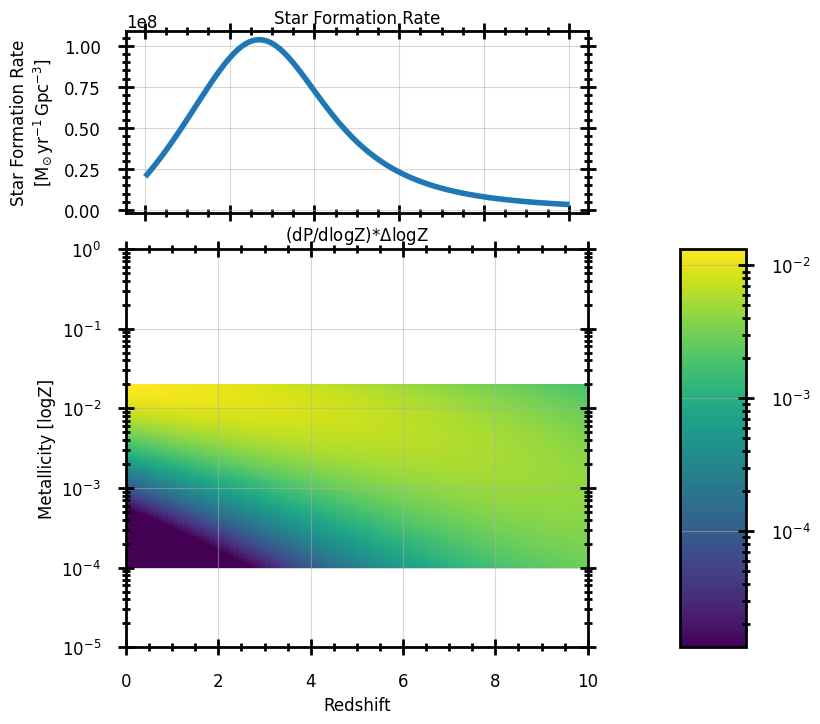

In [11]:
# growl_catalog = build_growl_catalog()
dco_type='BBH'
process_dataset(folder_path=folder_path, sfr_plotting=True)




#### read in the merger rate at redshift z ~0.25, this is what we will aim to predict

In [16]:

output_hdf5_filename = os.path.join(folder_path, "sspc_output.h5")
yield_data = read_yields(output_hdf5_filename, redshift_key="0.125")

print('For this model the total BBH merger rate = ', np.sum(yield_data), ' [Gpc^-3, yr^-1]')



For this model the total BBH merger rate =  0.16188747031189452  [Gpc^-3, yr^-1]
